## Power Tuning Spectra

c:\Users\wahlm\Documents\School\Research\Allison\Codes\Dev-table\Plotting\utils\spectrometerdata.py:215: RuntimeWarning: divide by zero encountered in divide
  self._y_axis_data = 10 * np.log10(linear_y_data * self.total_power_mW / integral / delta_x)
c:\Users\wahlm\Documents\School\Research\Allison\Codes\Dev-table\Plotting\utils\spectrometerdata.py:215: RuntimeWarning: invalid value encountered in divide
  self._y_axis_data = 10 * np.log10(linear_y_data * self.total_power_mW / integral / delta_x)


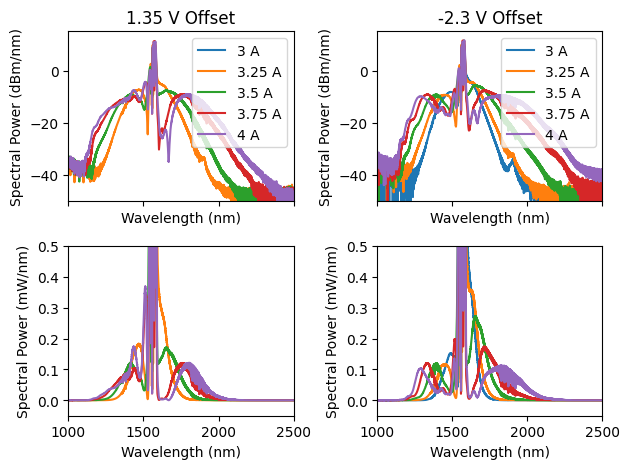

In [9]:

# Plots every spectrum in a user-selected folder. Works for the Yokogawa spectrometer.
import matplotlib.pyplot as plt
from utils.spectrometerdata import OSAData, readFromFiles
from pathlib import Path

if __name__ == "__main__":
    directorypath = Path(
        r'C:\Users\wahlm\Documents\School\Research\Allison\Tunable Pump\Pulse Optimization and Spectrum Generation\12-4-23 New NDHNLF Spectra\Current variation\1.35V')
    raw_data = readFromFiles(directorypath)
    labels = ('3 A', '3.25 A', '3.5 A', '3.75 A', '4 A')
              
    powers_mW = [0,183.5,
187.5,
193.5,
204.6,
213.5]

    data = [OSAData(dat, ('nm', 'dBm/nm'), labels[i], powers_mW[i], frep_MHz=60.5) for i, dat in enumerate(raw_data)]

    fig, axs = plt.subplots(2, 2, sharex=True)

    for datum in data:
        datum.y_axis_units = 'dBm/nm'
        axs[0,0].plot(datum._x_axis_data, datum.y_axis_data, label=datum.label)
    axs[0,0].set_xlabel('Wavelength (nm)')
    axs[0,0].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')
    axs[0,0].legend()
    axs[0,0].set_title('1.35 V Offset')

    for datum in data:
        datum.y_axis_units = 'mW/nm'
        axs[1,0].plot(datum._x_axis_data, datum.y_axis_data, label=datum.label)
    axs[1,0].set_xlabel('Wavelength (nm)')
    axs[1,0].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')

    directorypath = Path(r'C:\Users\wahlm\Documents\School\Research\Allison\Tunable Pump\Pulse Optimization and Spectrum Generation\12-4-23 New NDHNLF Spectra\Current variation\-2.3V')
    raw_data = readFromFiles(directorypath)

    labels = ('3 A', '3.25 A', '3.5 A', '3.75 A', '4 A')
    powers_mW = (186.5,
194.5,
206.5,
216.7,
217.6)
    data = [OSAData(dat, ('nm', 'dBm/nm'), labels[i], powers_mW[i], frep_MHz=60.5) for i, dat in enumerate(raw_data)]
    for datum in data:
        datum.y_axis_units = 'dBm/nm'
        axs[0,1].plot(datum._x_axis_data, datum.y_axis_data, label=datum.label)
    axs[0,1].set_xlabel('Wavelength (nm)')
    axs[0,1].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')
    axs[0,1].legend()
    axs[0,1].set_title('-2.3 V Offset')

    for datum in data:
        datum.y_axis_units = 'mW/nm'
        axs[1,1].plot(datum._x_axis_data, datum.y_axis_data, label=datum.label)
    axs[1,1].set_xlabel('Wavelength (nm)')
    axs[1,1].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')

    for ax in axs.flatten():
        ax.set_xlim([1000, 2500])
    axs[0,0].set_ylim([-50, 15])
    axs[0,1].set_ylim([-50, 15])
    axs[1,0].set_ylim([-.05, .5])
    axs[1,1].set_ylim([-.05, .5])
    
    plt.tight_layout()
    plt.show()

## Rep Rate Tuning Spectra, Background Subtracted

c:\Users\wahlm\Documents\School\Research\Allison\Codes\Dev-table\Plotting\utils\spectrometerdata.py:215: RuntimeWarning: divide by zero encountered in log10
  self._y_axis_data = 10 * np.log10(linear_y_data * self.total_power_mW / integral / delta_x)


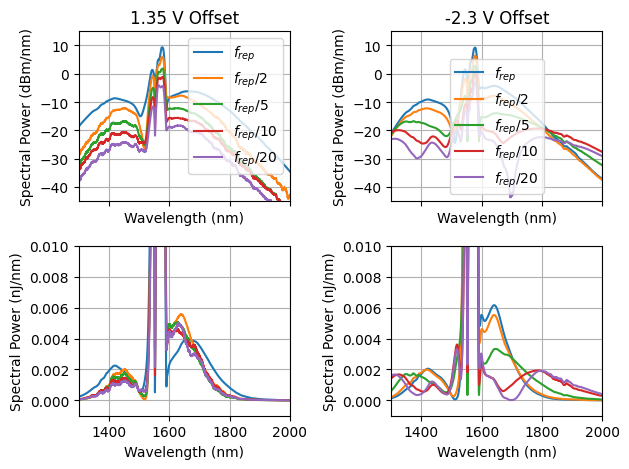

In [12]:


# Plots every spectrum in a user-selected folder. Works for the Yokogawa spectrometer.
from matplotlib import style
import matplotlib.pyplot as plt
from utils.spectrometerdata import OSAData, readFromFiles
from pathlib import Path
from scipy.signal import savgol_filter


c_nm_ps = 299792.458

fig, axs = plt.subplots(2, 2, sharex=True)

directorypath = Path(
    r'C:\Users\wahlm\Documents\School\Research\Allison\Tunable Pump\Pulse Optimization and Spectrum Generation\12-4-23 New NDHNLF Spectra\Rep rate variation\1.35V')
savepath = Path(r'C:\Users\wahlm\Documents\School\Research\Allison\Papers\tunable-pump-seed') / 'spectra_by_rep_rate.eps'
save_files = False

raw_data = readFromFiles(directorypath)
labels = (r'$f_{rep}$',
            r'$f_{rep}/2$',
            r'$f_{rep}/5$',
            r'$f_{rep}/10$',
            r'$f_{rep}/20$',
            'background'
            )
frep_frac = [1, 1/2, 1/5, 1/10, 1/20, 0]
is_background = (False, False, False, False, False, True)   
powers_mW = [216.4,
147.9,
106.9,
93.2,
84.8,
76.7] 

data = [OSAData(dat, ('nm', 'dBm/nm'), labels[i], powers_mW[i], frep_MHz=frep_frac[i] * 60.56, is_background=is_background[i]) for i, dat in enumerate(raw_data)]
# Background subtraction
for datum in data:
    datum.y_axis_units = 'mW/nm'
for i, datum in enumerate(data[:-1]):
    datum.y_axis_data = datum.y_axis_data - (1 - frep_frac[i]) * data[-1].y_axis_data
    datum.y_axis_data = savgol_filter(datum.y_axis_data, window_length=200, polyorder=3)
    datum.total_power_mW = datum.total_power_mW - (1 - frep_frac[i]) * data[-1].total_power_mW 

data = data[:-1]   
    

for datum in data:
    datum.y_axis_units = 'dBm/nm'
    axs[0,0].plot(datum.x_axis_data, datum.y_axis_data, label=datum.label)
axs[0,0].set_title('1.35 V Offset')   
axs[0,0].set_xlabel('Wavelength (nm)')
axs[0,0].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')
axs[0,0].legend()
axs[0,0].grid()


for datum in data:
    datum.y_axis_units = 'nJ/nm'

    axs[1,0].plot(datum.x_axis_data, datum.y_axis_data, label=datum.label)
axs[1,0].set_xlabel('Wavelength (nm)')
axs[1,0].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')
axs[1,0].grid()

#next chunk of data
directorypath = Path(
    r'C:\Users\wahlm\Documents\School\Research\Allison\Tunable Pump\Pulse Optimization and Spectrum Generation\12-4-23 New NDHNLF Spectra\Rep rate variation\-2.3V')
savepath = Path(r'C:\Users\wahlm\Documents\School\Research\Allison\Papers\tunable-pump-seed') / 'spectra_by_rep_rate.eps'
save_files = False

raw_data = readFromFiles(directorypath)
labels = (r'$f_{rep}$',
            r'$f_{rep}/2$',
            r'$f_{rep}/5$',
            r'$f_{rep}/10$',
            r'$f_{rep}/20$',
            'background'
            )
frep_frac = [1, 1/2, 1/5, 1/10, 1/20, 0]
is_background = (False, False, False, False, False, True)   
powers_mW = [213,
116.7,
58.8,
39.7,
30,
20.4]

data = [OSAData(dat, ('nm', 'dBm/nm'), labels[i], powers_mW[i], frep_MHz=frep_frac[i] * 60.56, is_background=is_background[i]) for i, dat in enumerate(raw_data)]
# Background subtraction
for datum in data:
    datum.y_axis_units = 'mW/nm'
for i, datum in enumerate(data[:-1]):
    datum.y_axis_data = datum.y_axis_data - (1 - frep_frac[i]) * data[-1].y_axis_data
    datum.y_axis_data = savgol_filter(datum.y_axis_data, window_length=200, polyorder=3)
    datum.total_power_mW = datum.total_power_mW - (1 - frep_frac[i]) * data[-1].total_power_mW 

data = data[:-1]   
    

for datum in data:
    datum.y_axis_units = 'dBm/nm'
    axs[0,1].plot(datum.x_axis_data, datum.y_axis_data, label=datum.label)
    
axs[0,1].set_title('-2.3 V Offset')   
axs[0,1].set_xlabel('Wavelength (nm)')
axs[0,1].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')
axs[0,1].legend()
axs[0,1].grid()


for datum in data:
    datum.y_axis_units = 'nJ/nm'

    axs[1,1].plot(datum.x_axis_data, datum.y_axis_data, label=datum.label)
axs[1,1].set_xlabel('Wavelength (nm)')
axs[1,1].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')
axs[1,1].grid()

for ax in axs.flatten():
    ax.set_xlim([1300, 2000])

axs[0,0].set_ylim([-45, 15])
axs[0,1].set_ylim([-45, 15])
axs[1,0].set_ylim([-.001, .01])
axs[1,1].set_ylim([-.001, .01])


# fig.canvas.manager.window.showMaximized()  # toggle fullscreen mode
plt.tight_layout()
if save_files:
    plt.savefig(savepath, dpi=500)
plt.show()


## Rep Rate Tunability w/out background subtraction

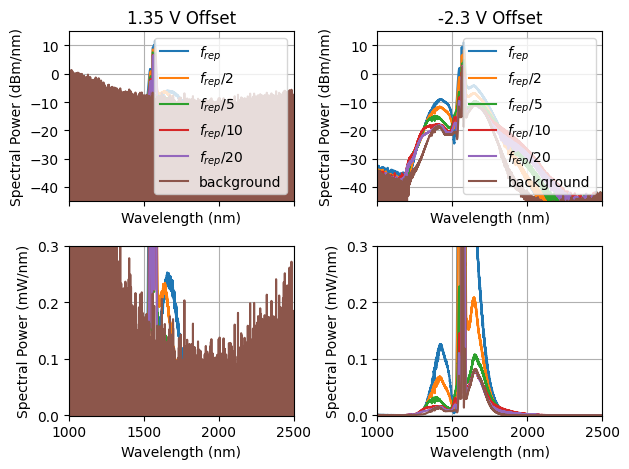

In [1]:
# Plots every spectrum in a user-selected folder. Works for the Yokogawa spectrometer.
from matplotlib import style
import matplotlib.pyplot as plt
from utils.spectrometerdata import OSAData, readFromFiles
from pathlib import Path
from scipy.signal import savgol_filter


c_nm_ps = 299792.458

fig, axs = plt.subplots(2, 2, sharex=True)

directorypath = Path(
    r'C:\Users\wahlm\Documents\School\Research\Allison\Tunable Pump\Pulse Optimization and Spectrum Generation\12-4-23 New NDHNLF Spectra\Rep rate variation\1.35V')
savepath = Path(r'C:\Users\wahlm\Documents\School\Research\Allison\Papers\tunable-pump-seed') / 'spectra_by_rep_rate.eps'
save_files = False

raw_data = readFromFiles(directorypath)
labels = (r'$f_{rep}$',
            r'$f_{rep}/2$',
            r'$f_{rep}/5$',
            r'$f_{rep}/10$',
            r'$f_{rep}/20$',
            'background'
            )
frep_frac = [1, 1/2, 1/5, 1/10, 1/20, 0]
is_background = (False, False, False, False, False, True)   
powers_mW = [216.4,
147.9,
106.9,
93.2,
84.8,
76.7] 

data = [OSAData(dat, ('nm', 'dBm/nm'), labels[i], powers_mW[i]) for i, dat in enumerate(raw_data)]
    

for datum in data:
    datum.y_axis_units = 'dBm/nm'
    axs[0,0].plot(datum.x_axis_data, datum.y_axis_data, label=datum.label)
axs[0,0].set_title('1.35 V Offset')   
axs[0,0].set_xlabel('Wavelength (nm)')
axs[0,0].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')
axs[0,0].legend()
axs[0,0].grid()


for datum in data:
    datum.y_axis_units = 'mW/nm'

    axs[1,0].plot(datum.x_axis_data, datum.y_axis_data, label=datum.label)
axs[1,0].set_xlabel('Wavelength (nm)')
axs[1,0].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')
axs[1,0].grid()

#next chunk of data
directorypath = Path(
    r'C:\Users\wahlm\Documents\School\Research\Allison\Tunable Pump\Pulse Optimization and Spectrum Generation\12-4-23 New NDHNLF Spectra\Rep rate variation\-2.3V')
savepath = Path(r'C:\Users\wahlm\Documents\School\Research\Allison\Papers\tunable-pump-seed') / 'spectra_by_rep_rate.eps'
save_files = False

raw_data = readFromFiles(directorypath)
labels = (r'$f_{rep}$',
            r'$f_{rep}/2$',
            r'$f_{rep}/5$',
            r'$f_{rep}/10$',
            r'$f_{rep}/20$',
            'background'
            )
frep_frac = [1, 1/2, 1/5, 1/10, 1/20, 0]
is_background = (False, False, False, False, False, True)   
powers_mW = [213,
116.7,
58.8,
39.7,
30,
20.4]

data = [OSAData(dat, ('nm', 'dBm/nm'), labels[i], powers_mW[i]) for i, dat in enumerate(raw_data)]
    

for datum in data:
    datum.y_axis_units = 'dBm/nm'
    axs[0,1].plot(datum.x_axis_data, datum.y_axis_data, label=datum.label)
    
axs[0,1].set_title('-2.3 V Offset')   
axs[0,1].set_xlabel('Wavelength (nm)')
axs[0,1].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')
axs[0,1].legend()
axs[0,1].grid()


for datum in data:
    datum.y_axis_units = 'mW/nm'

    axs[1,1].plot(datum.x_axis_data, datum.y_axis_data, label=datum.label)
axs[1,1].set_xlabel('Wavelength (nm)')
axs[1,1].set_ylabel(f'Spectral Power ({data[0].y_axis_units})')
axs[1,1].grid()

for ax in axs.flatten():
    ax.set_xlim([1000, 2500])

axs[0,0].set_ylim([-45, 15])
axs[0,1].set_ylim([-45, 15])
axs[1,0].set_ylim([-.001, .3])
axs[1,1].set_ylim([-.001, .3])


# fig.canvas.manager.window.showMaximized()  # toggle fullscreen mode
plt.tight_layout()
if save_files:
    plt.savefig(savepath, dpi=500)
plt.show()
